In [1]:
! pip install matplotlib
! pip install pandas
! pip install scipy
! pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

from prepSpec import *

In [3]:
spec = np.array(pd.read_csv('preprocessing_spec.csv', index_col=None, header=None))
wn = spec[0, :]
spec = spec[1:,:]
labels = np.array(pd.read_csv('preprocessing_label.csv', index_col=None, header=None))[:,0]

In [4]:
### plot mean spectrum of each group
def plot_mean (wn, spec, labels, uni_labels, figsize=(7, 5), fontsize=12, title='', gap=0.05):
    
    plt.figure(figsize=figsize)
    
    for i, l in enumerate(uni_labels):
        spec_mean = spec[labels==l, :].mean(axis=0)
        spec_std = spec[labels==l, :].std(axis=0)
        plt.plot(wn, spec_mean + i*gap, label=l)
        plt.fill_between(wn, spec_mean + i*gap - spec_std, 
                         spec_mean + i*gap + spec_std, 
                         alpha = 0.2)
    plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
    plt.ylabel('Intensity / arb. u.', fontsize=15)
    plt.title(title)
    plt.legend(fontsize=15)

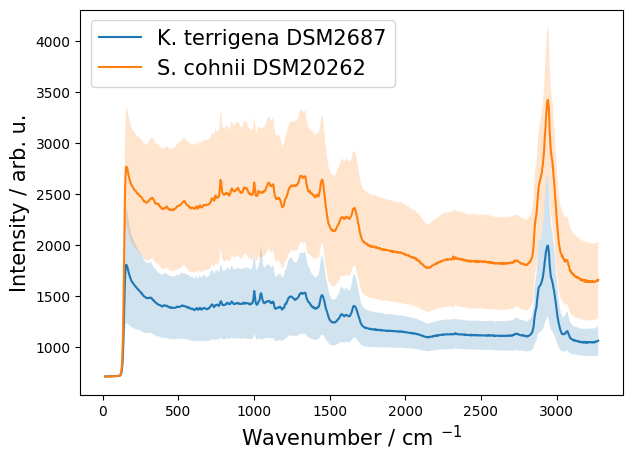

In [5]:
plot_mean(wn, spec, labels, np.unique(labels))

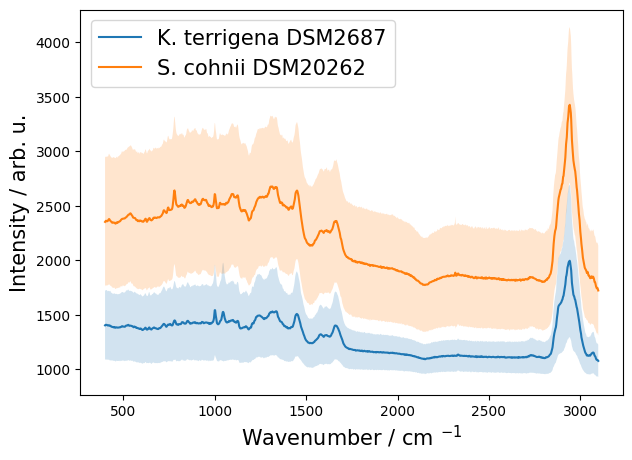

In [6]:
### interpolation

wn_new = np.array(range(400, 3100, 2))
wn_new, spec_interp = do_interpolation(spec, x_old = wn, x_new = wn_new)

plot_mean(wn_new, spec_interp, labels, np.unique(labels))

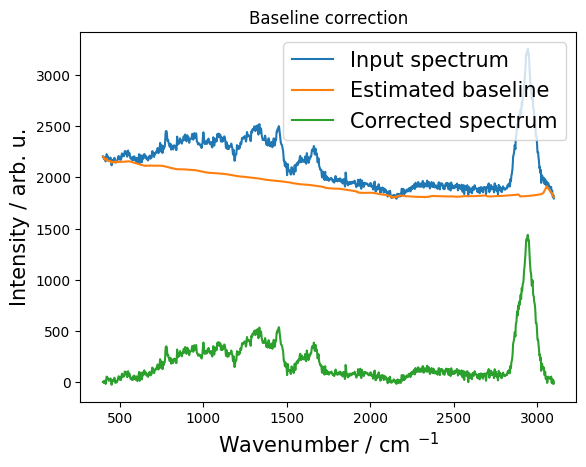

In [7]:
### baseline correction: iterations=100
spec_bg = snip(spec_interp, iterations=100, smoothing_window=9, lls=True, return_baseline=True)
plt.plot(wn_new, spec_interp[0,:], label='Input spectrum')
plt.plot(wn_new, spec_bg[0,:], label='Estimated baseline')
plt.plot(wn_new, spec_interp[0,:]-spec_bg[0,:], label='Corrected spectrum')

plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.title('Baseline correction')
plt.legend(fontsize=15)

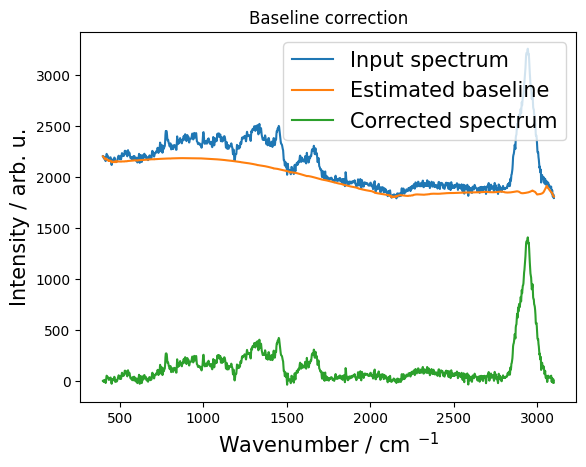

In [8]:
### baseline correction: iterations=50
spec_bg = snip(spec_interp, iterations=50, smoothing_window=9, lls=True, return_baseline=True)

plt.plot(wn_new, spec_interp[0,:], label='Input spectrum')
plt.plot(wn_new, spec_bg[0,:], label='Estimated baseline')
plt.plot(wn_new, spec_interp[0,:]-spec_bg[0,:], label='Corrected spectrum')

plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.title('Baseline correction')
plt.legend(fontsize=15)

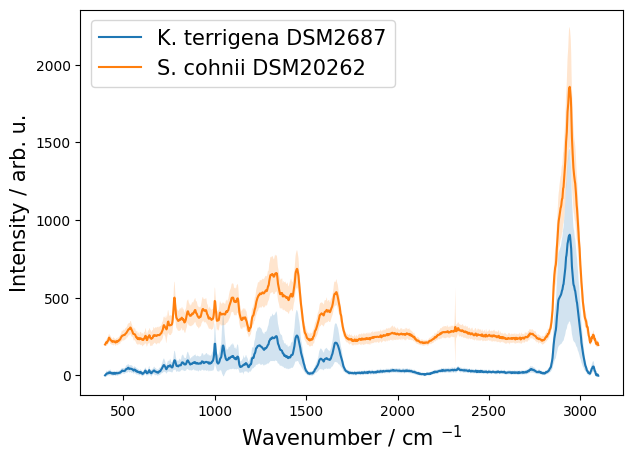

In [9]:
spec_bc = snip(spec_interp, iterations=50, smoothing_window=9, lls=True, return_baseline=False)
plot_mean(wn_new, spec_bc, labels, np.unique(labels), gap=200)

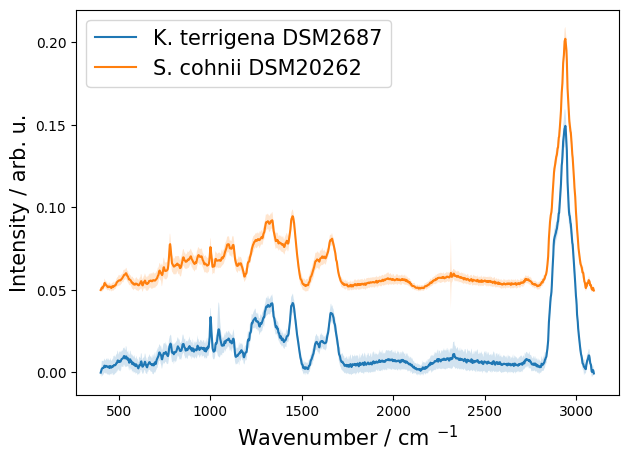

In [10]:
### normalization
spec_norm = norm_spectra(spec_bc, norm_method='vector')
plot_mean(wn_new, spec_norm, labels, np.unique(labels))

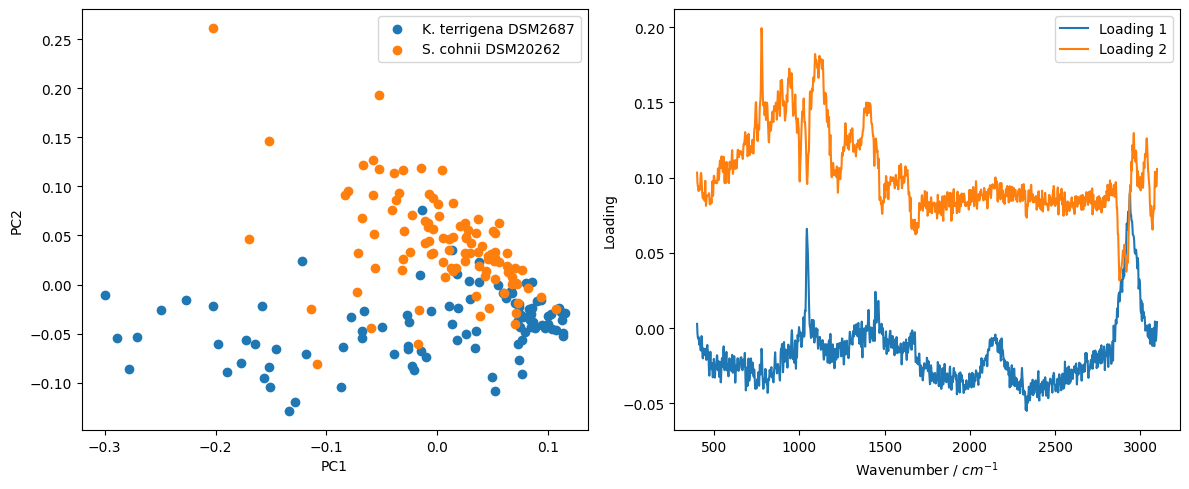

In [12]:
### feature extraction (PCA)

### perform PCA on preprocessed data
pca = PCA(n_components=10)
pca.fit(spec_norm)
scores = pca.transform(spec_norm)
loadings = pca.components_

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for l in np.unique(labels):
    ax[0].scatter(scores[labels==l,0], scores[labels==l,1], label=l)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].legend()

ax[1].plot(wn_new, loadings[0, :], label='Loading 1')
ax[1].plot(wn_new, loadings[1, :]+0.1, label='Loading 2')
ax[1].set_xlabel('Wavenumber / $cm^{-1}$')
ax[1].set_ylabel('Loading')
ax[1].legend()

plt.tight_layout()
plt.show()

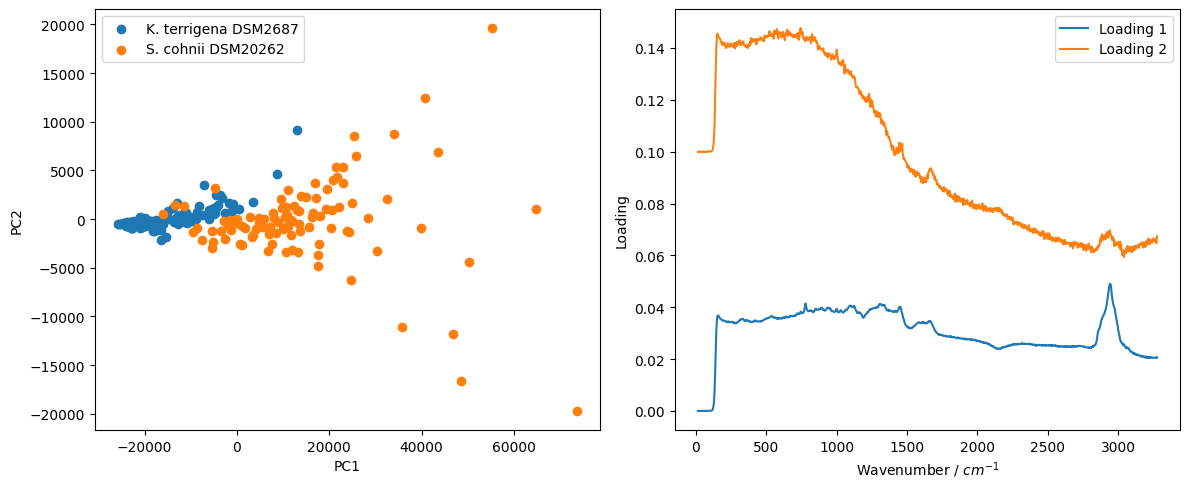

In [13]:
### perform PCA on raw data
pca = PCA(n_components=10)
pca.fit(spec)
scores = pca.transform(spec)
loadings = pca.components_

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for l in np.unique(labels):
    ax[0].scatter(scores[labels==l,0], scores[labels==l,1], label=l)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].legend()

ax[1].plot(wn, loadings[0, :], label='Loading 1')
ax[1].plot(wn, loadings[1, :]+0.1, label='Loading 2')
ax[1].set_xlabel('Wavenumber / $cm^{-1}$')
ax[1].set_ylabel('Loading')
ax[1].legend()

plt.tight_layout()
plt.show()